# Inspect Loop 4 / 4.5

Classifies cells from the new Loop 4/4.5 experiment with the existing classifier, then checks clusters and markers of interest.

In [5]:
import logging
import os
import sys
import traceback
import yaml

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [6]:
adata_l4 = sc.read_h5ad("../../../project_folder/data/gdrive/LPHO014/Loop2_Loop2p5_Loop3_Loop4_Loop4p5/Loop4_logicle_500k.h5ad")

In [7]:
adata_l4p5 = sc.read_h5adadata_l4 = sc.read_h5ad("../../../project_folder/data/gdrive/LPHO014/Loop2_Loop2p5_Loop3_Loop4_Loop4p5/Loop4p5_logicle_500k.h5ad")

In [8]:
adata_l4.obs["experiment_number"].unique()

['259']
Categories (1, object): ['259']

In [9]:
adata_l4p5.obs["experiment_number"].unique()

['260']
Categories (1, object): ['260']

In [10]:
adata_l4.obs['tpo_[ng_ml]']

194101-2    25.0
124395-4    25.0
209718-0    25.0
36682-3     25.0
60793-1     25.0
            ... 
259786-3    25.0
251424-0    25.0
26592-4     25.0
110370-2    25.0
185398-1    25.0
Name: tpo_[ng_ml], Length: 500000, dtype: float64

In [11]:
adata_l4p5.obs['tpo_[ng_ml]']

19353-3     100.0
71652-4     100.0
35675-3     100.0
176125-2    100.0
116080-3    100.0
            ...  
49016-2     100.0
25156-1     100.0
137128-3    100.0
77339-5     100.0
101419-3    100.0
Name: tpo_[ng_ml], Length: 500000, dtype: float64

In [48]:
sc.pp.pca(adata_l4)
sc.pp.neighbors(adata_l4)
sc.tl.umap(adata_l4)

In [49]:
sc.pp.pca(adata_l4p5)
sc.pp.neighbors(adata_l4p5)
sc.tl.umap(adata_l4p5)

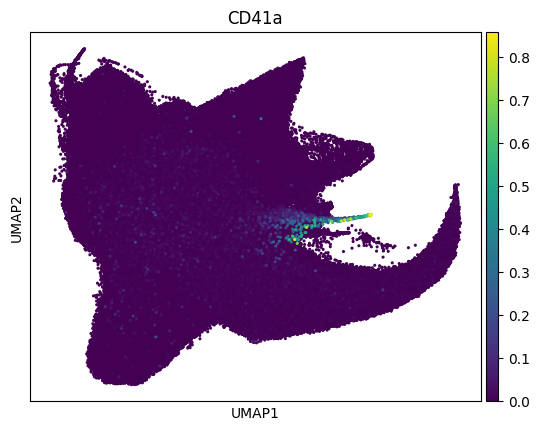

In [50]:
sc.pl.umap(adata_l4, color="CD41a", s=20)

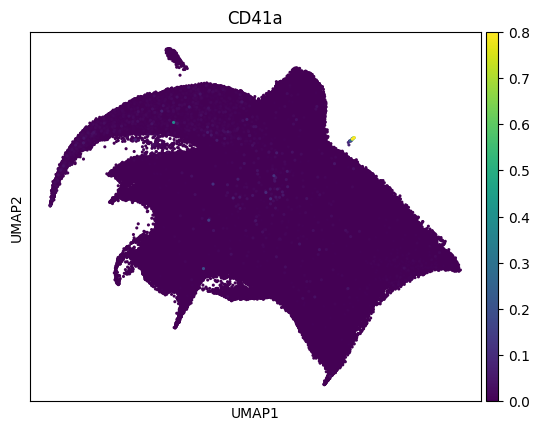

In [51]:
sc.pl.umap(adata_l4p5, color="CD41a", s=20, vmax=0.8)

## Classify cells of new experiment with classifier. 

In [58]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm",
                        "annotation=bloodplus_loop3"
                    ])

ANNOTATION_CFG_FILE = "../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [53]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [54]:
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

(dict_keys(['mean', 'std']), dict_keys(['mean', 'std']))

In [59]:
X_channel_loop4 = adata_l4.X
X_channel_loop4p5 = adata_l4p5.X

# The model 
X_channel_loop4 = (X_channel_loop4 - channel_params["mean"])/channel_params["std"]
X_channel_loop4p5 = (X_channel_loop4p5 - channel_params["mean"])/channel_params["std"]

X_scatter_loop4 = []
X_scatter_loop4p5 = []
for col in config.annotation.scatter_columns:
    col_vals_loop4 = adata_l4.obs[col].astype(float).values
    col_vals_loop4p5 = adata_l4p5.obs[col].astype(float).values
    X_scatter_loop4.append(col_vals_loop4)
    X_scatter_loop4p5.append(col_vals_loop4p5)
    
X_scatter_loop4 = np.stack(X_scatter_loop4, axis=1)
X_scatter_loop4 = (X_scatter_loop4 - scatter_params["mean"])/scatter_params["std"]
X_scatter_loop4p5 = np.stack(X_scatter_loop4p5, axis=1)
X_scatter_loop4p5 = (X_scatter_loop4p5 - scatter_params["mean"])/scatter_params["std"]


X_loop4 = np.concatenate(
    (
        X_channel_loop4, X_scatter_loop4
    ), axis=1
)

X_loop4p5 = np.concatenate(
    (
        X_channel_loop4p5, X_scatter_loop4p5
    ), axis=1
)

print(f"{X_channel_loop4.shape=} {X_scatter_loop4.shape=}")
print(f"{X_channel_loop4p5.shape=} {X_scatter_loop4p5.shape=}")

X_channel_loop4.shape=(500000, 20) X_scatter_loop4.shape=(500000, 6)
X_channel_loop4p5.shape=(500000, 20) X_scatter_loop4p5.shape=(500000, 6)


In [60]:
dataloader_loop4 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop4)), 
    batch_size=4026,
    shuffle=False
)

dataloader_loop4p5 = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_loop4p5)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions_loop4 = []
ct_predictions_loop4p5 = []

with torch.no_grad():
    for batch in tqdm(dataloader_loop4):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop4.append(y_pred.cpu().detach().numpy())
ct_predictions_loop4 = np.concatenate(ct_predictions_loop4)

with torch.no_grad():
    for batch in tqdm(dataloader_loop4p5):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions_loop4p5.append(y_pred.cpu().detach().numpy())
ct_predictions_loop4p5 = np.concatenate(ct_predictions_loop4p5)

100%|██████████| 125/125 [00:02<00:00, 44.55it/s]


In [61]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [63]:
ct_predictions_str_loop4 = classes[ct_predictions_loop4]
ct_predictions_str_loop4p5 = classes[ct_predictions_loop4p5]

In [65]:
adata_l4.obs["cell_type"] = ct_predictions_str_loop4
adata_l4p5.obs["cell_type"] = ct_predictions_str_loop4p5

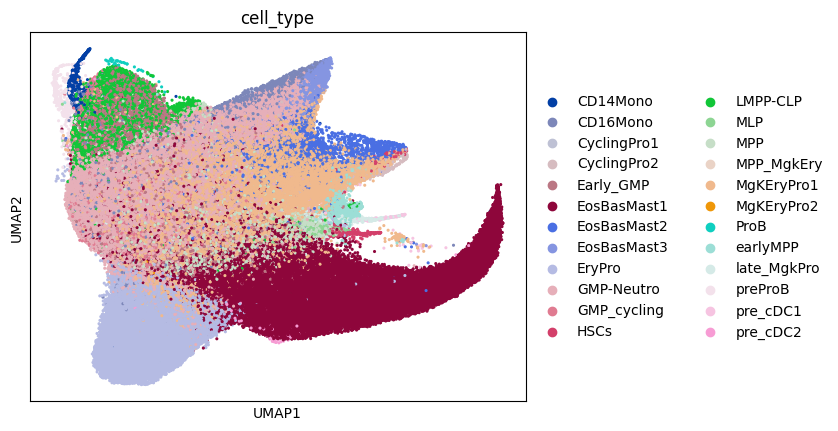

In [67]:
sc.pl.umap(adata_l4, color="cell_type", s=20)

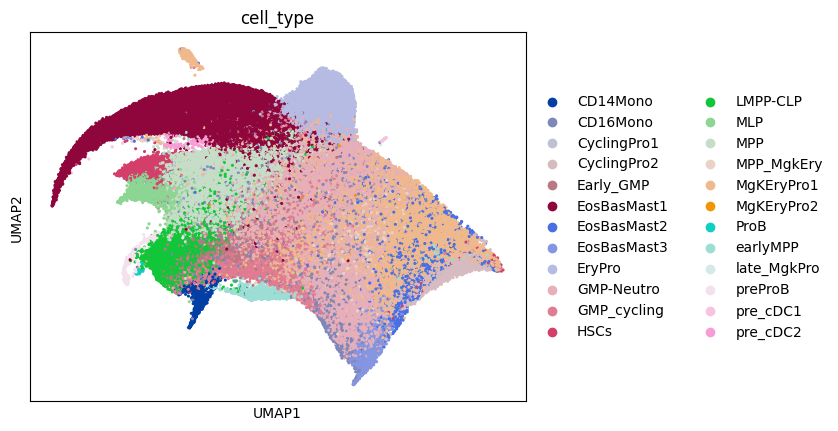

In [72]:
sc.pl.umap(adata_l4p5, color="cell_type", s=20)

In [75]:
adata_l4.write_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4_500k_residual_processed.h5ad")
adata_l4p5.write_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4p5_500k_residual_processed.h5ad")

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


In [76]:
del adata_l4
del adata_l4p5

In [90]:
# unique_protocols = adata_joint.obs.loc[:, protocol_cols + ["experiment_number"]].drop_duplicates()

In [91]:
# unique_protocols

## Check clusters 

In [2]:
adata_l4 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4_500k_residual_processed.h5ad")
adata_l4p5 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4p5_500k_residual_processed.h5ad")

In [3]:
adata_l4.obs.cell_type.value_counts()/adata_l4.shape[0]

cell_type
GMP-Neutro     0.272748
MgKEryPro1     0.234260
EosBasMast1    0.205172
EryPro         0.068664
Early_GMP      0.055800
MPP            0.054170
LMPP-CLP       0.030052
GMP_cycling    0.025800
CD16Mono       0.018878
EosBasMast2    0.016490
EosBasMast3    0.005308
earlyMPP       0.003472
MLP            0.001866
CD14Mono       0.001462
HSCs           0.001150
CyclingPro2    0.001142
late_MgkPro    0.001064
preProB        0.001062
MPP_MgkEry     0.000386
pre_cDC2       0.000330
MgKEryPro2     0.000298
pre_cDC1       0.000296
ProB           0.000086
CyclingPro1    0.000044
Name: count, dtype: float64

In [4]:
adata_l4p5.obs.cell_type.value_counts()/adata_l4p5.shape[0]

cell_type
GMP-Neutro     0.311724
MgKEryPro1     0.207660
MPP            0.107994
EosBasMast1    0.104630
GMP_cycling    0.055464
CD16Mono       0.044850
LMPP-CLP       0.035514
Early_GMP      0.029928
EryPro         0.025418
EosBasMast2    0.021684
MPP_MgkEry     0.021238
EosBasMast3    0.008052
MLP            0.005860
HSCs           0.005594
CyclingPro2    0.005318
earlyMPP       0.003082
CD14Mono       0.002874
MgKEryPro2     0.001522
preProB        0.000794
pre_cDC2       0.000600
pre_cDC1       0.000080
ProB           0.000060
CyclingPro1    0.000036
late_MgkPro    0.000024
Name: count, dtype: float64

## Check marker 

In [12]:
# adata_l1 = sc.read_h5ad("../../../project_folder/output/loops/data/loop0/adata_500k.h5ad")
# adata_l4 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4_500k_residual_processed.h5ad")
# adata_l4p5 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/processed/adata_loop4p5_500k_residual_processed.h5ad")

adata_l0 = sc.read_h5ad("../../../project_folder/output/loops/data/loop0/adata_full.h5ad")
adata_259 = sc.read_h5ad("../../../project_folder/output/loops/data/loop4/replicate/adata_full_residual.h5ad")
adata_260 = sc.read_h5ad("../../../project_folder/data/gdrive/LPHO014/Loop2_Loop2p5_Loop3_Loop4_Loop4p5/Loop4p5_logicle.h5ad")

In [13]:
adata_21 = adata_l0[adata_l0.obs.experiment_number==21]
adata_205 = adata_l0[adata_l0.obs.experiment_number==205]
adata_259 = adata_l4[adata_l4.obs.experiment_number=="259"]
adata_260 = adata_l4p5[adata_l4p5.obs.experiment_number=="260"]

In [14]:
cd41a_expression = {"cd41a": np.concatenate([adata_21[:, "CD41a"].X.toarray().ravel(),
                                             adata_205[:, "CD41a"].X.toarray().ravel(),
                                             adata_l4[:, "CD41a"].X.toarray().ravel(),
                                             adata_l4p5[:, "CD41a"].X.toarray().ravel()]), 
                   "experiment_number": ["tpo0" for _ in range(len(adata_21))] + ["tpo2p5" for _ in range(len(adata_205))] + ["tpo25" for _ in range(len(adata_259))] + ["loop100" for _ in range(len(adata_260))]}

cd235a_expression = {"cd235a": np.concatenate([adata_21[:, "CD235a"].X.toarray().ravel(),
                                                adata_205[:, "CD235a"].X.toarray().ravel(),
                                                adata_l4[:, "CD235a"].X.toarray().ravel(),
                                                adata_l4p5[:, "CD235a"].X.toarray().ravel()]), 
                     "experiment_number": ["tpo0" for _ in range(len(adata_21))] + ["tpo2p5" for _ in range(len(adata_205))] + ["tpo25" for _ in range(len(adata_259))] + ["loop100" for _ in range(len(adata_260))]}

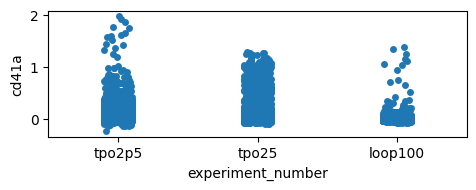

In [29]:
plt.figure(figsize=(5,2))
cd41a_expression_df = pd.DataFrame(cd41a_expression)
sns.stripplot(cd41a_expression_df, x="experiment_number", y="cd41a")
plt.savefig("../plots/tpo_cd41a.png", dpi=500)
plt.tight_layout()
plt.savefig("../plots/tpo_235a.png", dpi=500)
plt.show()

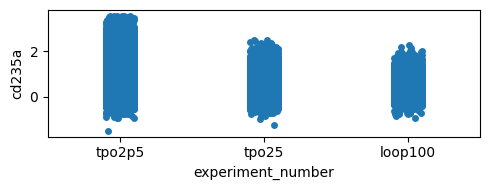

In [30]:
plt.figure(figsize=(5,2))
cd235a_expression_df = pd.DataFrame(cd235a_expression)
sns.stripplot(cd235a_expression_df, x="experiment_number", y="cd235a")
plt.tight_layout()
plt.savefig("../plots/tpo_235a.png", dpi=500)
plt.show()